1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA

2. Load Dataset

In [2]:
df = pd.read_csv("dataset/store_customers.csv")

print("\nFirst 5 Rows:\n")
print(df.head())


First 5 Rows:

   CustomerID Gender   Age  Annual Income (k$)  Spending Score (1-100)
0        1000      M  39.0                59.9                    58.0
1        1001      M  34.0                48.4                    37.0
2        1002      F  40.0                70.5                    26.0
3        1003      F  47.0                81.1                    30.0
4        1004      F  33.0                42.1                    58.0


3. Dataset Inspection

In [3]:
print("\nDataset Info:\n")
print(df.info())

print("\nMissing Values:\n")
print(df.isnull().sum())


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    object 
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 39.2+ KB
None

Missing Values:

CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64


4. Handle Missing Values

In [4]:
df['Gender'] = df['Gender'].fillna(
    df['Gender'].mode()[0]
)

df['Age'] = df['Age'].fillna(
    df['Age'].mean()
)

df['Annual Income (k$)'] = df[
    'Annual Income (k$)'
].fillna(
    df['Annual Income (k$)'].mean()
)

df['Spending Score (1-100)'] = df[
    'Spending Score (1-100)'
].fillna(
    df['Spending Score (1-100)'].mean()
)

5. Verify Cleaned Data

In [5]:
print("\nMissing Values After Cleaning:\n")
print(df.isnull().sum())


Missing Values After Cleaning:

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


6. Encode Gender

In [6]:
encoder = LabelEncoder()

df['Gender'] = encoder.fit_transform(
    df['Gender']
)

print("\nEncoded Gender Values:\n")
print(df['Gender'].head())


Encoded Gender Values:

0    1
1    1
2    0
3    0
4    0
Name: Gender, dtype: int64


7. Feature Selection

In [7]:
X = df[
    [
       
        'Age',
        'Annual Income (k$)',
        'Spending Score (1-100)'
    ]
]

print("\nSelected Features:\n")
print(X.head())


Selected Features:

    Age  Annual Income (k$)  Spending Score (1-100)
0  39.0                59.9                    58.0
1  34.0                48.4                    37.0
2  40.0                70.5                    26.0
3  47.0                81.1                    30.0
4  33.0                42.1                    58.0


8. Feature Scaling

In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nScaled Features Shape:")
print(X_scaled.shape)


Scaled Features Shape:
(1000, 3)


9. Elbow Method

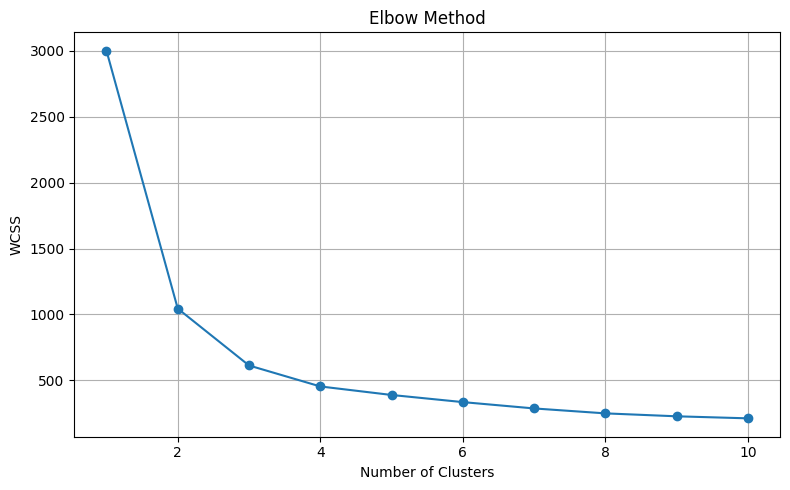

In [9]:
wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.grid(True)

plt.tight_layout()
plt.savefig("outputs/elbow_method.png", dpi=300)
plt.show()

Insight:

Elbow Method helps determine the optimal number of clusters.

10. Silhouette Score Comparison

In [10]:
silhouette_scores = []

for i in range(2,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

print("\nSilhouette Scores:\n")

for i, score in enumerate(
    silhouette_scores,
    start=2
):
    print(f"K = {i} --> Score = {score:.3f}")


Silhouette Scores:

K = 2 --> Score = 0.570
K = 3 --> Score = 0.481
K = 4 --> Score = 0.377
K = 5 --> Score = 0.329
K = 6 --> Score = 0.323
K = 7 --> Score = 0.321
K = 8 --> Score = 0.321
K = 9 --> Score = 0.316
K = 10 --> Score = 0.304


11. Apply K-Means Clustering

In [11]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

print("\nCluster Assigned Successfully")


Cluster Assigned Successfully


12. Cluster Analysis

In [12]:
print("\nCluster Mean Analysis:\n")

print(
    df.groupby('Cluster').mean(
        numeric_only=True
    )
)


Cluster Mean Analysis:

          CustomerID    Gender        Age  Annual Income (k$)  \
Cluster                                                         
0        1837.414062  0.476562  66.695312          107.578125   
1        1419.488235  0.476471  35.519831           49.124556   
2        1484.042254  0.455399  45.102984           81.082621   
3        1459.510972  0.485893  27.319547           29.486361   

         Spending Score (1-100)  
Cluster                          
0                      4.984375  
1                     47.887010  
2                     30.265943  
3                     60.437761  


13. Customer Type Labeling

In [13]:
cluster_names = {

    0: "Premium Customers",

    1: "Budget Customers",

    2: "Regular Customers",

    3: "High Potential Customers"
}

df['Customer Type'] = df[
    'Cluster'
].map(cluster_names)

print("\nCustomer Types Added:\n")

print(
    df[
        [
            'Cluster',
            'Customer Type'
        ]
    ].head()
)


Customer Types Added:

   Cluster      Customer Type
0        1   Budget Customers
1        1   Budget Customers
2        2  Regular Customers
3        2  Regular Customers
4        1   Budget Customers


14. Customer Distribution Visualization


Customer Distribution:

Customer Type
Budget Customers            340
High Potential Customers    319
Regular Customers           213
Premium Customers           128
Name: count, dtype: int64


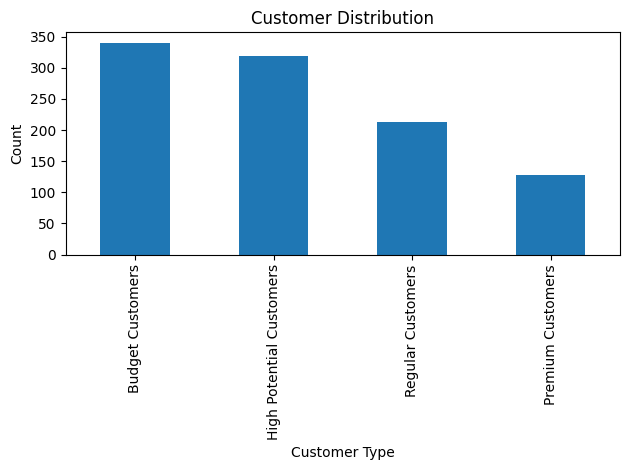

In [15]:
print("\nCustomer Distribution:\n")

print(
    df['Customer Type'].value_counts()
)

df['Customer Type'].value_counts().plot(
    kind='bar'
)

plt.title("Customer Distribution")

plt.xlabel("Customer Type")

plt.ylabel("Count")



plt.tight_layout()
plt.savefig("outputs/customer_distribution.png", dpi=300)
plt.show()

15. Save Output Dataset

In [16]:
df.to_csv(
    "outputs/customer_segments.csv",
    index=False
)

print("\nOutput Saved Successfully")


Output Saved Successfully


16. Business Insights

In [17]:
print("\nBusiness Insights:\n")

for cluster in sorted(
    df['Cluster'].unique()
):

    print(f"\nCluster {cluster}")

    print(
        df[
            df['Cluster'] == cluster
        ][
            [
                'Annual Income (k$)',
                'Spending Score (1-100)'
            ]
        ].mean()
    )


Business Insights:


Cluster 0
Annual Income (k$)        107.578125
Spending Score (1-100)      4.984375
dtype: float64

Cluster 1
Annual Income (k$)        49.124556
Spending Score (1-100)    47.887010
dtype: float64

Cluster 2
Annual Income (k$)        81.082621
Spending Score (1-100)    30.265943
dtype: float64

Cluster 3
Annual Income (k$)        29.486361
Spending Score (1-100)    60.437761
dtype: float64


Additional Insights:
=====================
1)Premium Customers:
    - High income and high spending customers.
    - Best targets for loyalty programs.
2)Budget Customers:
    - Price-sensitive audience.
    - Respond better to discounts.
3)Regular Customers:
    - Moderate income and spending behavior.
    - Stable customer base.
4)High Potential Customers:
    - High engagement potential.
    - Can be targeted using personalized marketing.

17. Silhouette Score Evaluation

In [18]:
score = silhouette_score(
    X_scaled,
    clusters
)

print("\nFinal Silhouette Score:")
print(score)


Final Silhouette Score:
0.3765238596004373


Interpretation:
    -A score closer to 1 indicates better-separated clusters

18. PCA Dimensionality Reduction

In [19]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(
    X_scaled
)

19. PCA Cluster Visualization

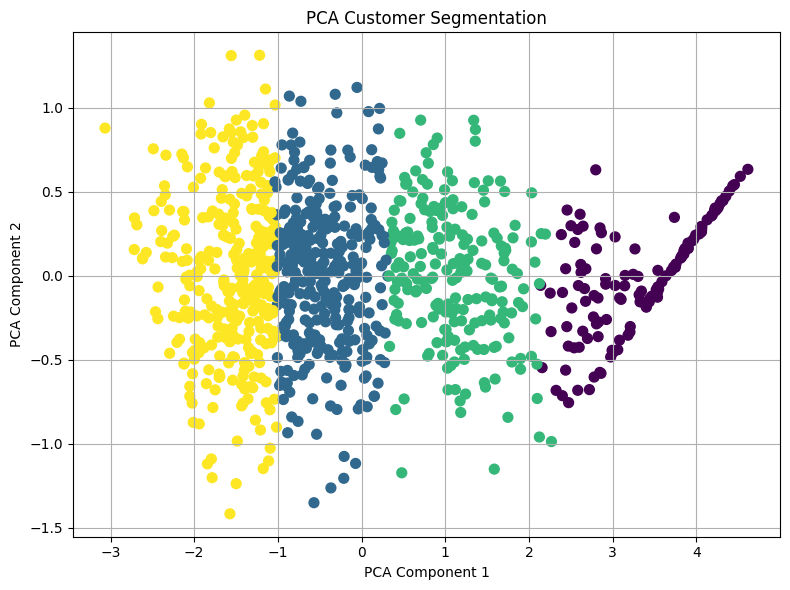

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df['Cluster'],
    s=50
)

plt.xlabel("PCA Component 1")

plt.ylabel("PCA Component 2")

plt.title(
    "PCA Customer Segmentation"
)

plt.grid(True)

plt.tight_layout()

plt.show()

Insight:
  - PCA reduces high-dimensional data into 2D for visualization while preserving important information.

20. PCA Centroid Visualization

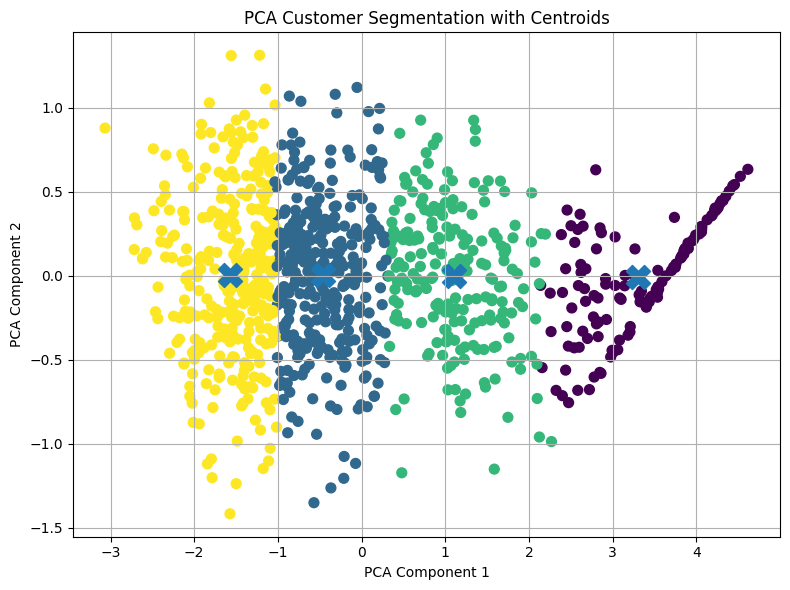

In [20]:
pca_centroids = pca.transform(
    kmeans.cluster_centers_
)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df['Cluster'],
    s=50
)

plt.scatter(
    pca_centroids[:,0],
    pca_centroids[:,1],
    s=300,
    marker='X'
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.title(
    "PCA Customer Segmentation with Centroids"
)

plt.grid(True)

plt.tight_layout()
plt.savefig("outputs/pca_clusters.png", dpi=300)
plt.show()

21. Income vs Spending Visualization

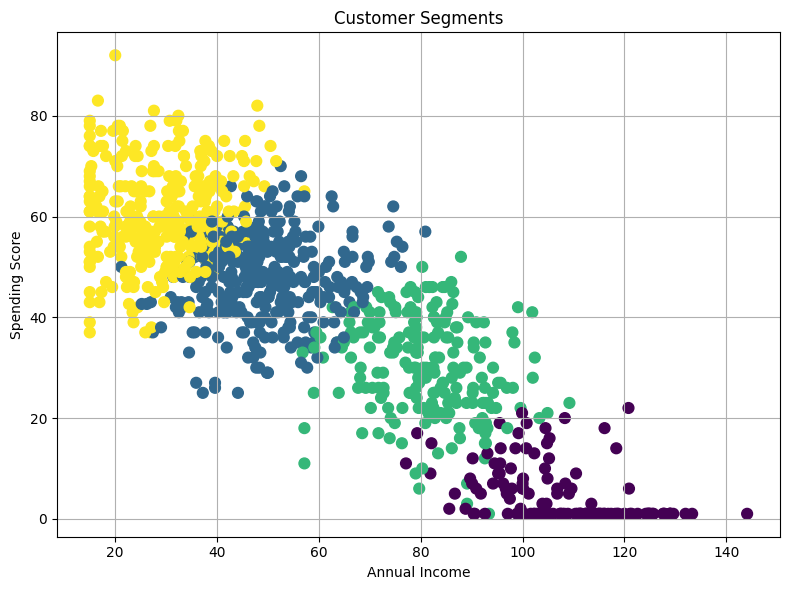

In [21]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    s=60
)

plt.xlabel("Annual Income")

plt.ylabel("Spending Score")

plt.title(
    "Customer Segments"
)

plt.grid(True)

plt.tight_layout()
plt.savefig("outputs/income_spending.png", dpi=300)
plt.show()

22. Age vs Spending Visualization

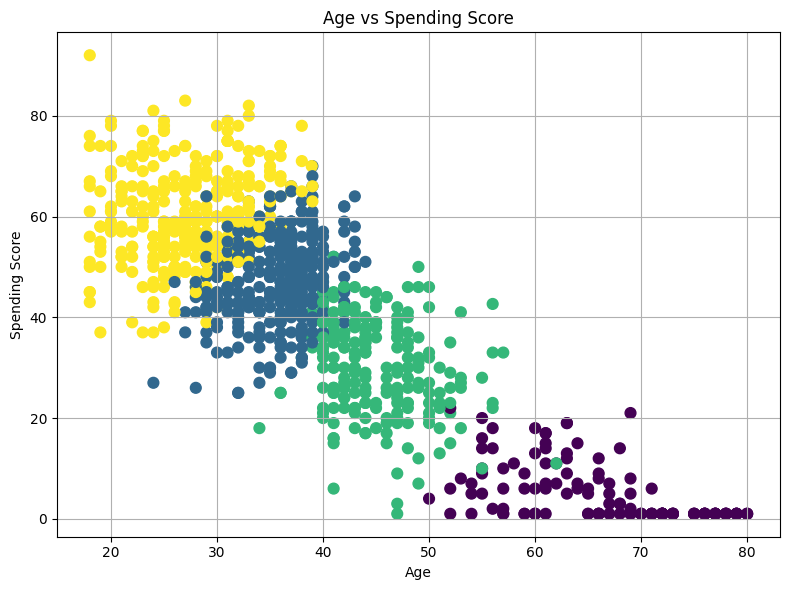

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Age'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    s=60
)

plt.xlabel("Age")

plt.ylabel("Spending Score")

plt.title("Age vs Spending Score")

plt.grid(True)

plt.tight_layout()
plt.savefig("outputs/age_spending.png", dpi=300)
plt.show()

23. Explained Variance Ratio

In [23]:
print(
    "\nExplained Variance Ratio:\n"
)

print(
    pca.explained_variance_ratio_
)


Explained Variance Ratio:

[0.90964983 0.06339386]


24. Final Cluster Summary

In [24]:
cluster_summary = df.groupby(
    'Customer Type'
).mean(
    numeric_only=True
)

print("\nFinal Cluster Summary:\n")

print(cluster_summary)


Final Cluster Summary:

                           CustomerID    Gender        Age  \
Customer Type                                                
Budget Customers          1419.488235  0.476471  35.519831   
High Potential Customers  1459.510972  0.485893  27.319547   
Premium Customers         1837.414062  0.476562  66.695312   
Regular Customers         1484.042254  0.455399  45.102984   

                          Annual Income (k$)  Spending Score (1-100)  Cluster  
Customer Type                                                                  
Budget Customers                   49.124556               47.887010      1.0  
High Potential Customers           29.486361               60.437761      3.0  
Premium Customers                 107.578125                4.984375      0.0  
Regular Customers                  81.082621               30.265943      2.0  


25. Save Trained Models

In [25]:

joblib.dump(
    kmeans,
    "models/kmeans_model.pkl"
)

joblib.dump(
    scaler,
    "models/scaler.pkl"
)

print("\nModels Saved Successfully")


Models Saved Successfully
